In [1]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats
import yaml
import importlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter

plt.style.use('latex_default.mplstyle')

In [2]:
folder = "/work/bd0620/b309199/linear-mws"
flavor = "pmap_mpdata"
# flavor = "pmap_ppm"
# flavor = "eulag_compressi"
# flavor = "eulag_anelastic"

image_folder = f"../data/pmap"
os.makedirs(image_folder,exist_ok=True)

sims = [f"{flavor}_MW_000km", f"{flavor}_MW_001km", f"{flavor}_MW_002km", f"{flavor}_MW_003km", f"{flavor}_MW_005km", f"{flavor}_MW_010km", 
        f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km", 
        f"{flavor}_MW_125km", f"{flavor}_MW_150km"]

sims = [f"{flavor}_MW_002km", f"{flavor}_MW_005km", f"{flavor}_MW_010km", 
        f"{flavor}_MW_025km", f"{flavor}_MW_050km", f"{flavor}_MW_075km", f"{flavor}_MW_100km"]

labels = [f"L: 2$\,$km", f"L: 5$\,$km", f"L: 10$\,$km", f"L: 25$\,$km", f"L: 50$\,$km", f"L: 75$\,$km", f"L: 100$\,$km"]

# f"{flavor}_tau2_MW_003km"

In [3]:
ds_list = []
cfgs = []
t = -1
for sim in sims:
    model = flavor.split("_")[0]
    fpath = os.path.join(folder, sim)
    
    if model == "pmap":
        ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": [0]})
        cfgs.append(cfg)
    else:
        _, ds, _, _ = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
    ds_list.append(ds)

color_palette = [
    "#D72638",  # Crimson Red - Primary
    "#F46036",  # Coral Orange - Accent
    "#F6AE2D",  # Golden Sand - Highlight
    "mediumorchid",  # Teal Green - Complementary
    "#2F2F2F",  # Charcoal Gray - Neutral Base
    "grey",  # Mist White - Light Neutral
    "#58A4B0",  # Sky Blue - Cool Accent
    "#133C55"   # Midnight Blue - Deep Shade
]

if model == "pmap":
    U = cfg['ambient_fields']['velocity_x']
    grav = cfg['constants']['gravity0']
    stb00 = cfg['ambient_fields']['stb00']
    N = np.sqrt(stb00*grav)
    rho00 = cfg['ambient_fields']['rho00']
    AMP = cfg['define_orography']['args']['amplitude']
    f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0']*np.pi/180)
    print(cfg['constants'])
else:
    U = ds['u'][0,0].values
    grav = ds.g
    stb00 = ds.st
    N = np.sqrt(stb00*grav)
    rho00 = 1
    # rho00 = ds['rh0'][0,0,0].values
    AMP = ds.amp
    f = ds.fcr0 * np.sin(ds.ang*np.pi/180)

# [i for i in ds.variables] 

{'radius_sphere': 6368000.0, 'gravity0': 9.806159973144531, 'Ravo': 6.022136680382177e+23, 'Rbol': 1.380658045430573e-23, 'Rmd': 28.964399337768555, 'Rmv': 18.015300750732422, 'gamma': 1.399999976158142, 'p0': 100000.0, 't0': 288.0, 'tht0': 288.0, 'ee0': 611.0, 'hlat': 2530000.0, 'fcoriolis0': 0.00014583999291062355, 'angle0': 43.290000915527344, 'lat_geonp': 90.0, 'lon_geonp': 180.0, 'R': 8.314511458452216, 'Rd': 287.0596887403906, 'cpd': 1004.7089533665966, 'Rd_cpd': 0.2857142735500723, 'cap': 0.2857142735500723}


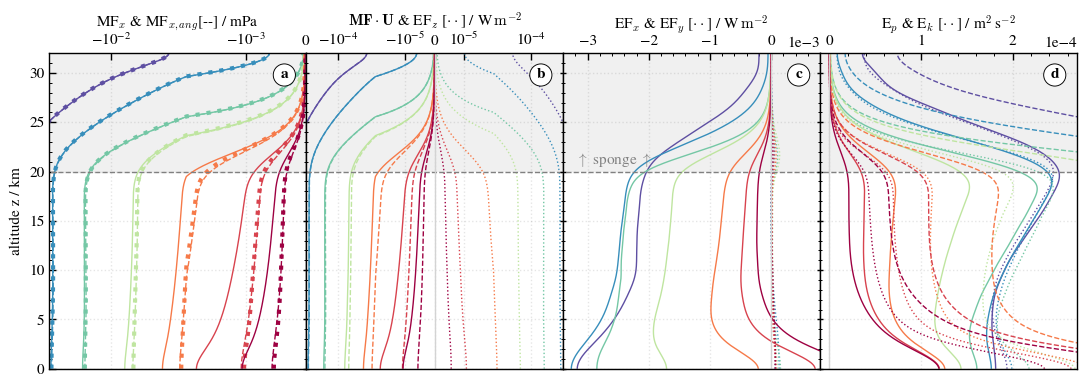

In [7]:
gskw = {'wspace':0}
fig, axes = plt.subplots(1,4,figsize=(11,4),sharey=True, gridspec_kw=gskw)

ax0 = axes[0]
ax1 = axes[1]
ax2 = axes[2]
ax3 = axes[3]

num_colors = 10
cmap = plt.get_cmap('Spectral')
COLS = [cmap(i / (num_colors - 1)) for i in range(num_colors)]
COLS.pop(3)
COLS.pop(3)
COLS.pop(3)
COLS = COLS[::-1]
# COLS=['darkblue','slateblue','darkviolet', 'mediumorchid', 'lightcoral','tomato', 'firebrick', 'black']
ZLIM = [0,32]

abs_factor = 1
i=0
t = -1
for sim in sims:
    model = flavor.split("_")[0]
    fpath = os.path.join(folder, sim)
    
    if model == "pmap":
        ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": [0]})
        u0 = cfg['ambient_fields']['velocity_x']
        grav = cfg['constants']['gravity0']
        stb00 = cfg['ambient_fields']['stb00']
        N = np.sqrt(stb00*grav)
        rho00 = cfg['ambient_fields']['rho00']
        p00 = cfg['ambient_fields']['p00']
        # AMP = cfg['define_orography']['args']['amplitude']
        f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0']*np.pi/180)
        cap = cfg['constants']['cap']

        if cfg['absorber']['xboundaries']:
            nrelax0 = int(cfg['absorber']['widthx'] / cfg['dx'] * abs_factor)
            nrelax1 = cfg['nx'] - nrelax0
        else:
            nrelax0 = 0
            nrelax1 = cfg['nx']
    else:
        _, ds, _, _ = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
    
    zcr = ds['zcr'][:,0].values / 1000

    u = ds['u'].values
    uprime = u - u0
    v = ds['v'].values
    vprime = v
    w = ds['w'].values
    rho = ds['rho'].values
    th = ds['th'].values
    thprime = ds['thprime'].values
    p = ds['p'].values
    pprime = ds['pprime'].values
    
    the = th - thprime
    dthdz = np.gradient(the, cfg['dz'], axis=0)
    
    # --------- Calculate fluxes -------------------- # 
    uw   = w * uprime
    vw   = w * vprime
    mfx  = rho * uw
    mfx_ang = rho * (uw - f * vprime * thprime / dthdz)
    mfy  = rho * vw
    mfy_ang = rho * (vw + f * uprime * thprime / dthdz)
    MF_U = mfx * u + mfy * v # = -EFz
    MF_U_ang = mfx_ang * u + mfy_ang * v
    
    efx = uprime * pprime # h14, EFx1
    efy = vprime * pprime
    # efx = np.sqrt(efx**2+efy**2)
    efz = w * pprime # h13, EFz1

    tte = the * (p/p00)**cap # T_env (TODO: use pr0 instead of p)
    tloc = th * (p/p00)**cap # T
    # tte = the * (p/p00)**ds.cap # T_env (TODO: use pr0 instead of p)
    # tloc = th * (p/p00)**ds.cap # T
    tprime = tloc-tte
    
    ek = 1/2 * (uprime**2 + vprime**2 + w**2)
    ep = 1/2*(grav/N)**2 * (tprime/tte)**2 # * ds['rh0'][t,:,y,:] #  potential energy density
    # --------- Calculate fluxes -------------------- # 
        
    # -> horizontal mean
    # uw_m = uw[:,nrelax0:nrelax1].mean(axis=1)
    # vw_m = vw[:,nrelax0:nrelax1].mean(axis=1)
    mfx_m = mfx[:,nrelax0:nrelax1].mean(axis=1)
    mfx_ang_m = mfx_ang[:,nrelax0:nrelax1].mean(axis=1)
    mfy_m = mfy[:,nrelax0:nrelax1].mean(axis=1)
    mfy_ang_m = mfy_ang[:,nrelax0:nrelax1].mean(axis=1)
    ep_m = ep[:,nrelax0:nrelax1].mean(axis=1)
    ek_m = ek[:,nrelax0:nrelax1].mean(axis=1)
    efx_m = efx[:,nrelax0:nrelax1].mean(axis=1)
    efy_m = efy[:,nrelax0:nrelax1].mean(axis=1)
    efz_m = efz[:,nrelax0:nrelax1].mean(axis=1)
    MF_U_m = MF_U[:,nrelax0:nrelax1].mean(axis=1)
    MF_U_ang_m = MF_U_ang[:,nrelax0:nrelax1].mean(axis=1)
    
     # --- 1D filter --- #
    dz = 50
    lambdaz = 6250

    mfx_m = filter.gaussian_filter_fft_1D(mfx_m, lambdaz, dz)
    mfx_ang_m = filter.gaussian_filter_fft_1D(mfx_ang_m, lambdaz, dz)
    mfy_m = filter.gaussian_filter_fft_1D(mfy_m, lambdaz, dz)
    mfy_ang_m = filter.gaussian_filter_fft_1D(mfy_ang_m, lambdaz, dz)

    ep_m = filter.gaussian_filter_fft_1D(ep_m, lambdaz, dz)
    efx_m = filter.gaussian_filter_fft_1D(efx_m, lambdaz, dz)
    efy_m = filter.gaussian_filter_fft_1D(efy_m, lambdaz, dz)
    efz_m = filter.gaussian_filter_fft_1D(efz_m, lambdaz, dz)
    MF_U_m = filter.gaussian_filter_fft_1D(MF_U_m, lambdaz, dz)
    MF_U_ang_m = filter.gaussian_filter_fft_1D(MF_U_ang_m, lambdaz, dz)
    ek_m = filter.gaussian_filter_fft_1D(ek_m, lambdaz, dz)
    
    # -- VISUALIZATION -- #
    lw = 1
    ax0.plot(1000*mfx_m, zcr, lw=lw, color=COLS[i], label=labels[i])
    ax0.plot(1000*mfx_ang_m, zcr, lw=lw, ls='dashed', color=COLS[i], label=labels[i])
    ax0.plot(1000*(mfx_ang_m-mfy_ang_m), zcr, lw=lw+2, ls='dotted', color=COLS[i], label=labels[i])
    ax1.plot(efz_m, zcr, lw=lw, label=labels[i], ls='dotted', color=COLS[i])
    ax1.plot(MF_U_m, zcr, lw=lw, color=COLS[i])
    ax1.plot(MF_U_ang_m, zcr, lw=lw, ls='dashed', color=COLS[i])
    ax2.plot(efx_m, zcr, lw=lw, color=COLS[i])
    ax2.plot(efy_m, zcr, lw=lw, ls='dotted', color=COLS[i])
    ax3.plot(ep_m, zcr, lw=lw, label=labels[i], color=COLS[i])
    ax3.plot(ek_m, zcr, lw=lw, ls='dotted', color=COLS[i])
    ax3.plot(ep_m + ek_m, zcr, lw=lw, ls='dashed', color=COLS[i])
    
    i+=1
    
# -- FORMAT AXES -- #
ax0.set_xlabel('MF$_x$ & MF$_{x,ang}$[--] / mPa')
ax1.set_xlabel(r"$\mathbf{MF} \cdot \mathbf{U}$ & EF$_z$ [$\cdot \cdot$] / W$ \, \mathrm{m}^{-2}$")
# ax1.set_xlabel(r"$\vec{MF} \cdot \vec{U}$ & EF$_z$ [$\cdot \cdot$] / W m$^{-2}$")
# ax2.set_xlabel(r"EF$_x$ / W$ \, \mathrm{m}^{-2}$")
ax2.set_xlabel(r"EF$_x$ & EF$_y$ [$\cdot \cdot$] / W$ \, \mathrm{m}^{-2}$")
# ax3.set_xlabel('E$_P$ / J kg$^{-1}$')
ax3.set_xlabel('E$_p$ & E$_k$ [$\cdot \cdot$] / m$^2 \,$s$^{-2}$')

ax0.yaxis.set_minor_locator(AutoMinorLocator())

for ax in axes:
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis="y", which='both', direction="inout", right=False)
    ax.tick_params(axis="x", which='both', top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.xaxis.set_label_position('top')
ax0.tick_params(axis="y", which='both', direction="in")

# - SPONGE LAYER - #
lw_sponge = 1
hsponge = 20
ax0.hlines(y=hsponge, xmin=-20, xmax=200, lw=lw_sponge,ls='--',color='grey')
ax1.hlines(y=hsponge, xmin=-20, xmax=200, lw=lw_sponge,ls='--',color='grey')
ax2.hlines(y=hsponge, xmin=-20, xmax=200, lw=lw_sponge,ls='--',color='grey')
ax3.hlines(y=hsponge, xmin=-20, xmax=200, lw=lw_sponge,ls='--',color='grey')

sponge_label = r'$\uparrow$ sponge $\uparrow$'
ax2.text(0.05, 0.65, sponge_label, transform=ax2.transAxes, color='grey')

c3 = 'lightgrey'
htop = 32
alpha_sponge = 0.33
# axes[i,j].axhline(y=48, lw=1.5,ls='--',color='grey')
ax0.fill_between(ax0.get_xlim(), [hsponge,hsponge], [htop,htop], facecolor=c3, alpha=alpha_sponge)
ax1.fill_between(ax1.get_xlim(), [hsponge,hsponge], [htop,htop], facecolor=c3, alpha=alpha_sponge)
ax2.fill_between(ax2.get_xlim(), [hsponge,hsponge], [htop,htop], facecolor=c3, alpha=alpha_sponge)
ax3.fill_between(ax3.get_xlim(), [hsponge,hsponge], [htop,htop], facecolor=c3, alpha=alpha_sponge)


symb_ax = '-'
col_ax = 'lightgrey'
lw_ax = 1
ax0.hlines(y=0, xmin=-20, xmax=200, lw=lw_ax,ls=symb_ax,color=col_ax)
ax1.hlines(y=0, xmin=-20, xmax=200, lw=lw_ax,ls=symb_ax,color=col_ax)
ax2.hlines(y=0, xmin=-20, xmax=200, lw=lw_ax,ls=symb_ax,color=col_ax)
ax3.hlines(y=0, xmin=-20, xmax=200, lw=lw_ax,ls=symb_ax,color=col_ax)

ax0.vlines(x=0, ymin=-10, ymax=100, lw=lw_ax,ls=symb_ax,color=col_ax)
ax1.vlines(x=0, ymin=-10, ymax=100, lw=lw_ax,ls=symb_ax,color=col_ax)
ax2.vlines(x=0, ymin=-10, ymax=100, lw=lw_ax,ls=symb_ax,color=col_ax)
ax3.vlines(x=0, ymin=-10, ymax=100, lw=lw_ax,ls=symb_ax,color=col_ax)

# --- Labels and legend --- #
# ax3.legend(loc='lower right', framealpha=1, fontsize=11) # 'upper left'
# ax5.axis('off')

ax0.set_ylim(ZLIM)
ax0.set_ylabel(r'altitude z / km')

"""
ax0.set_xlim([-2,0.1]) # MFx
ax1.set_xlim([-0.025,0.025]) # EFz
ax2.set_xlim([-0.6,0.2]) # EFx
ax3.set_xlim([-0.001,0.04]) # Ep
ax4.set_xlim([-5,110])
"""

ax0.set_xlim([-0.038,0.00001]) # MFxd
ax0.set_xscale('symlog', linthresh=0.002)
ax1.set_xlim([-0.0004,0.0004]) # EFz
ax1.set_xscale('symlog', linthresh=0.00002)

ax2.set_xlim([-0.0034,0.0008]) # EFx
ax3.set_xlim([-0.00001,0.00027]) # Ep

# --- Limits and Sci format --- #
for ax in axes[2:4]:
    ax.ticklabel_format(axis='x', style='sci', scilimits=(-2,2))
    ax.figure.canvas.draw()  # Needed to populate offset text
    offset_text = ax.xaxis.get_offset_text()
    offset_text.set_visible(False)  # Hide default
    ax.annotate(offset_text.get_text(), xy=(1, 1.01), xycoords='axes fraction',
                ha='right', va='bottom')

# --- Text --- #
labs = ['a','b','c','d']
for ax, lab in zip(axes, labs):
    ax.text(1-0.07, 0.92, lab, horizontalalignment='right', transform=ax.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax.grid(visible=True)
    
# filter_label = '$\lambda_{z,filter}$: ' + str(lambdaz/1000) + 'km'
# ax3.text(0.575, 0.91, filter_label, transform=ax3.transAxes)

# --- Save figure --- #
# fig.suptitle(title_label)
fig.tight_layout()
fig_title = f'vertical_profiles_{flavor}_' + '{:03d}'.format(t) + '.png'
fig_title = f'vertical_profiles_{flavor}_' + '{:03d}'.format(t) + '_MFy.png'
# fig_title = f'vertical_profiles_legend.png'
fig.savefig(os.path.join(image_folder, fig_title), facecolor='w', edgecolor='w',
                    format='png', dpi=300, bbox_inches='tight')

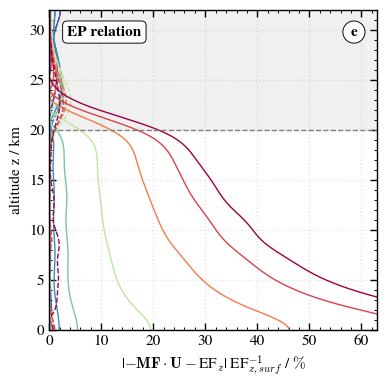

In [9]:
gskw = {'wspace':0}
fig, (ax0) = plt.subplots(1,1,figsize=(4,4),sharey=True, gridspec_kw=gskw)

abs_factor = 1
i=0
t = -1
for sim in sims:
    model = flavor.split("_")[0]
    fpath = os.path.join(folder, sim)
    
    if model == "pmap":
        ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": [0]})
        u0 = cfg['ambient_fields']['velocity_x']
        grav = cfg['constants']['gravity0']
        stb00 = cfg['ambient_fields']['stb00']
        N = np.sqrt(stb00*grav)
        rho00 = cfg['ambient_fields']['rho00']
        p00 = cfg['ambient_fields']['p00']
        # AMP = cfg['define_orography']['args']['amplitude']
        f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0']*np.pi/180)
        cap = cfg['constants']['cap']

        if cfg['absorber']['xboundaries']:
            nrelax0 = int(cfg['absorber']['widthx'] / cfg['dx'] * abs_factor)
            nrelax1 = cfg['nx'] - nrelax0
        else:
            nrelax0 = 0
            nrelax1 = cfg['nx']
    else:
        _, ds, _, _ = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
    
    zcr = ds['zcr'][:,0].values / 1000

    u = ds['u'].values
    uprime = u - u0
    v = ds['v'].values
    vprime = v
    w = ds['w'].values
    rho = ds['rho'].values
    th = ds['th'].values
    thprime = ds['thprime'].values
    p = ds['p'].values
    pprime = ds['pprime'].values
    
    the = th - thprime
    dthdz = np.gradient(the, cfg['dz'], axis=0)
    
    # --------- Calculate fluxes -------------------- # 
    uw   = w * uprime
    vw   = w * vprime
    mfx  = rho * uw
    mfx_ang = rho * (uw - f * vprime * thprime / dthdz)
    mfy  = rho * vw
    mfy_ang = rho * (vw + f * uprime * thprime / dthdz)
    MF_U = mfx * u + mfy * v # = -EFz
    MF_U_ang = mfx_ang * u + mfy_ang * v
    
    efx = uprime * pprime # h14, EFx1
    efy = vprime * pprime
    # efx = np.sqrt(efx**2+efy**2)
    efz = w * pprime # h13, EFz1

    tte = the * (p/p00)**cap # T_env (TODO: use pr0 instead of p)
    tloc = th * (p/p00)**cap # T
    # tte = the * (p/p00)**ds.cap # T_env (TODO: use pr0 instead of p)
    # tloc = th * (p/p00)**ds.cap # T
    tprime = tloc-tte
    
    ek = 1/2 * (uprime**2 + vprime**2 + w**2)
    ep = 1/2*(grav/N)**2 * (tprime/tte)**2 # * ds['rh0'][t,:,y,:] #  potential energy density
    # --------- Calculate fluxes -------------------- # 
        
    # -> horizontal mean
    mfx_m = mfx[:,nrelax0:nrelax1].mean(axis=1)
    mfx_ang_m = mfx_ang[:,nrelax0:nrelax1].mean(axis=1)
    # mfy_m = mfy[:,nrelax0:nrelax1].mean(axis=1)
    # mfy_ang_m = mfy_ang[:,nrelax0:nrelax1].mean(axis=1)
    ep_m = ep[:,nrelax0:nrelax1].mean(axis=1)
    ek_m = ek[:,nrelax0:nrelax1].mean(axis=1)
    efx_m = efx[:,nrelax0:nrelax1].mean(axis=1)
    efy_m = efy[:,nrelax0:nrelax1].mean(axis=1)
    efz_m = efz[:,nrelax0:nrelax1].mean(axis=1)
    MF_U_m = MF_U[:,nrelax0:nrelax1].mean(axis=1)
    MF_U_ang_m = MF_U_ang[:,nrelax0:nrelax1].mean(axis=1)
    
     # --- 1D filter --- #
    dz = 50
    lambdaz = 6250

    mfx_m = filter.gaussian_filter_fft_1D(mfx_m, lambdaz, dz)
    mfx_ang_m = filter.gaussian_filter_fft_1D(mfx_ang_m, lambdaz, dz)
    ep_m = filter.gaussian_filter_fft_1D(ep_m, lambdaz, dz)
    efx_m = filter.gaussian_filter_fft_1D(efx_m, lambdaz, dz)
    efy_m = filter.gaussian_filter_fft_1D(efy_m, lambdaz, dz)
    efz_m = filter.gaussian_filter_fft_1D(efz_m, lambdaz, dz)
    MF_U_m = filter.gaussian_filter_fft_1D(MF_U_m, lambdaz, dz)
    MF_U_ang_m = filter.gaussian_filter_fft_1D(MF_U_ang_m, lambdaz, dz)
    ek_m = filter.gaussian_filter_fft_1D(ek_m, lambdaz, dz)
    
    delta_ep = (-efz_m-MF_U_m)/efz_m[0]*100
    delta_ep_ang = (-efz_m-MF_U_ang_m)/efz_m[0]*100
    # delta_ep = subroutines.filter_1Dz(delta_ep,nz_avg,mode=0)

    def vertical_filter_for_ep_diff(data):
        ## REPLACE NANs AND PAD ##
        data = data.ffill(dim='z').bfill(dim='z')
        data = data.pad(z=nz_avg, mode="edge")
        # data = data.pad(x=nx_avg, mode="edge")

        ## FFT ##
        data=data.drop(['z','z_coord'],errors='ignore')
        da_fft = xrft.fft(data) # Fourier Transform w/ numpy.fft-like behavior   
        # da_fft = xrft.dft(data, true_phase=True, true_amplitude=True)

        ## GAUSSIAN RESPONSE FUNCTION ##
        response_func_z = np.exp(-da_fft.freq_z**2 * nz_avg**2)
        da_fft_low = da_fft * response_func_z

        ## INVERSE FFT ##
        data_filtered = xrft.ifft(da_fft_low)[nz_avg:ds.nz+nz_avg]
        return data_filtered
    
    # delta_ep = vertical_filter_for_ep_diff(delta_ep)
    # delta_ep_ang = vertical_filter_for_ep_diff(delta_ep_ang)
    
    # -- VISUALIZATION -- #
    lw=1
    # ax0.plot(abs(delta_ep[2:]), zcr[2:], lw=lw, label=labels[i], color=COLS[i]) # subtract absolute values!!!
    # ax0.plot(abs(delta_ep_ang[2:]), zcr[2:], lw=lw, ls='dashed', color=COLS[i])
    ax0.plot(abs(delta_ep), zcr, lw=lw, label=labels[i], color=COLS[i]) # subtract absolute values!!!
    ax0.plot(abs(delta_ep_ang), zcr, lw=lw, ls='dashed', color=COLS[i])
    
    i+=1
    
# -- FORMAT AXES -- #
ax0.set_xlabel(r"|$-\mathbf{MF} \cdot \mathbf{U} - $EF$_z$| EF$_{z,surf}^{-1}$ / $\%$")

ax0.yaxis.set_minor_locator(AutoMinorLocator())
ax0.xaxis.set_minor_locator(AutoMinorLocator())

ax0.tick_params(axis="y", which='both', right=True)

# - SPONGE LAYER - #
lw_sponge = 1
hsponge = 20
ax0.hlines(y=hsponge, xmin=-20, xmax=200, lw=lw_sponge,ls='--',color='grey')

# sponge_label = r'$\uparrow$ sponge layer $\uparrow$'
# ax0.text(0.05, 0.75, sponge_label, transform=ax0.transAxes, color='grey')

c3 = 'lightgrey'
htop = 34
alpha_sponge = 0.33
# axes[i,j].axhline(y=48, lw=1.5,ls='--',color='grey')
ax0.fill_between(ax0.get_xlim(), [hsponge,hsponge], [htop,htop], facecolor=c3, alpha=alpha_sponge)

symb_ax = '-'
col_ax = 'lightgrey'
lw_ax = 1
ax0.hlines(y=0, xmin=-20, xmax=200, lw=lw_ax,ls=symb_ax,color=col_ax)

ax0.vlines(x=0, ymin=-10, ymax=100, lw=lw_ax,ls=symb_ax,color=col_ax)

# --- Labels and legend --- #
# ax1.legend(loc='lower right') # 'upper left'
# ax5.axis('off')

ax0.set_ylim(ZLIM)
ax0.set_ylabel(r'altitude z / km')

# --- Limits and Sci format --- #
ax0.ticklabel_format(axis='x', style='sci', scilimits=(-2,2))
ax0.set_xlim([0,63]) # Delta

ax0.grid(visible=True)
ax0.tick_params(axis="x", which='both', top=True, bottom=True)

# --- Text --- #
zl = 0.92 
ax0.text(1-0.06, zl, 'e', horizontalalignment='right', transform=ax0.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
ax0.text(0.055, zl, 'EP relation', horizontalalignment='left', transform=ax0.transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

fig_title = f'vertical_profiles_epflux_{flavor}_' + '{:03d}'.format(t) + '.png'
fig.tight_layout()
fig.savefig(os.path.join(image_folder, fig_title), facecolor='w', edgecolor='w',
                format='png', dpi=300, bbox_inches='tight')

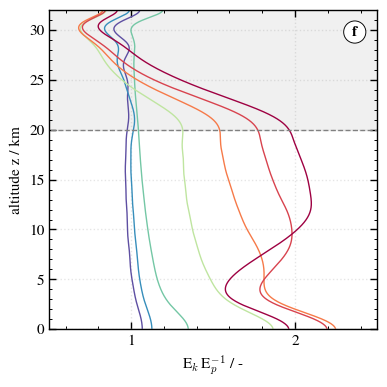

In [7]:
gskw = {'wspace':0}
fig, (ax0) = plt.subplots(1,1,figsize=(4,4),sharey=True, gridspec_kw=gskw)

abs_factor = 1
i=0
t = -1
for sim in sims:
    model = flavor.split("_")[0]
    fpath = os.path.join(folder, sim)
    
    if model == "pmap":
        ds, _, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": [0]})
        u0 = cfg['ambient_fields']['velocity_x']
        grav = cfg['constants']['gravity0']
        stb00 = cfg['ambient_fields']['stb00']
        N = np.sqrt(stb00*grav)
        rho00 = cfg['ambient_fields']['rho00']
        p00 = cfg['ambient_fields']['p00']
        # AMP = cfg['define_orography']['args']['amplitude']
        f = cfg['constants']['fcoriolis0'] * np.sin(cfg['constants']['angle0']*np.pi/180)
        cap = cfg['constants']['cap']

        if cfg['absorber']['xboundaries']:
            nrelax0 = int(cfg['absorber']['widthx'] / cfg['dx'] * abs_factor)
            nrelax1 = cfg['nx'] - nrelax0
        else:
            nrelax0 = 0
            nrelax1 = cfg['nx']
    else:
        _, ds, _, _ = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
    
    zcr = ds['zcr'][:,0].values / 1000

    u = ds['u'].values
    uprime = u - u0
    v = ds['v'].values
    vprime = v
    w = ds['w'].values
    rho = ds['rho'].values
    th = ds['th'].values
    thprime = ds['thprime'].values
    p = ds['p'].values
    pprime = ds['pprime'].values
    
    the = th - thprime
    dthdz = np.gradient(the, cfg['dz'], axis=0)
    
    # --------- Calculate fluxes -------------------- # 
    uw   = w * uprime
    vw   = w * vprime
    mfx  = rho * uw
    mfx_ang = rho * (uw - f * vprime * thprime / dthdz)
    mfy  = rho * vw
    mfy_ang = rho * (vw + f * uprime * thprime / dthdz)
    MF_U = mfx * u + mfy * v # = -EFz
    MF_U_ang = mfx_ang * u + mfy_ang * v
    
    efx = uprime * pprime # h14, EFx1
    efy = vprime * pprime
    # efx = np.sqrt(efx**2+efy**2)
    efz = w * pprime # h13, EFz1

    tte = the * (p/p00)**cap # T_env (TODO: use pr0 instead of p)
    tloc = th * (p/p00)**cap # T
    # tte = the * (p/p00)**ds.cap # T_env (TODO: use pr0 instead of p)
    # tloc = th * (p/p00)**ds.cap # T
    tprime = tloc-tte
    
    ek = 1/2 * (uprime**2 + vprime**2 + w**2)
    ep = 1/2*(grav/N)**2 * (tprime/tte)**2 # * ds['rh0'][t,:,y,:] #  potential energy density
    # --------- Calculate fluxes -------------------- # 
        
    # -> horizontal mean
    mfx_m = mfx[:,nrelax0:nrelax1].mean(axis=1)
    mfx_ang_m = mfx_ang[:,nrelax0:nrelax1].mean(axis=1)
    # mfy_m = mfy[:,nrelax0:nrelax1].mean(axis=1)
    # mfy_ang_m = mfy_ang[:,nrelax0:nrelax1].mean(axis=1)
    ep_m = ep[:,nrelax0:nrelax1].mean(axis=1)
    ek_m = ek[:,nrelax0:nrelax1].mean(axis=1)
    efx_m = efx[:,nrelax0:nrelax1].mean(axis=1)
    efy_m = efy[:,nrelax0:nrelax1].mean(axis=1)
    efz_m = efz[:,nrelax0:nrelax1].mean(axis=1)
    MF_U_m = MF_U[:,nrelax0:nrelax1].mean(axis=1)
    MF_U_ang_m = MF_U_ang[:,nrelax0:nrelax1].mean(axis=1)
    
     # --- 1D filter --- #
    dz = 50
    lambdaz = 6250

    mfx_m = filter.gaussian_filter_fft_1D(mfx_m, lambdaz, dz)
    mfx_ang_m = filter.gaussian_filter_fft_1D(mfx_ang_m, lambdaz, dz)
    ep_m = filter.gaussian_filter_fft_1D(ep_m, lambdaz, dz)
    efx_m = filter.gaussian_filter_fft_1D(efx_m, lambdaz, dz)
    efy_m = filter.gaussian_filter_fft_1D(efy_m, lambdaz, dz)
    efz_m = filter.gaussian_filter_fft_1D(efz_m, lambdaz, dz)
    MF_U_m = filter.gaussian_filter_fft_1D(MF_U_m, lambdaz, dz)
    MF_U_ang_m = filter.gaussian_filter_fft_1D(MF_U_ang_m, lambdaz, dz)
    ek_m = filter.gaussian_filter_fft_1D(ek_m, lambdaz, dz)
    
    # -- VISUALIZATION -- #
    ax0.plot(ek_m / ep_m, zcr, lw=1, label=labels[i], color=COLS[i]) # subtract absolute values!!!
    
    i+=1
    
# -- FORMAT AXES -- #
ax0.set_xlabel(r"E$_k\,$E$_p^{-1}$ / -")

ax0.yaxis.set_minor_locator(AutoMinorLocator())
ax0.xaxis.set_minor_locator(AutoMinorLocator())

ax0.tick_params(axis="y", which='both', right=True)

# - SPONGE LAYER - #
lw_sponge = 1
hsponge = 20
ax0.hlines(y=hsponge, xmin=-20, xmax=200, lw=lw_sponge,ls='--',color='grey')

# sponge_label = r'$\uparrow$ sponge layer $\uparrow$'
# ax0.text(0.05, 0.75, sponge_label, transform=ax0.transAxes, color='grey')

c3 = 'lightgrey'
htop = 34
alpha_sponge = 0.33
# axes[i,j].axhline(y=48, lw=1.5,ls='--',color='grey')
ax0.fill_between(ax0.get_xlim(), [hsponge,hsponge], [htop,htop], facecolor=c3, alpha=alpha_sponge)

symb_ax = '-'
col_ax = 'lightgrey'
lw_ax = 1
ax0.hlines(y=0, xmin=-20, xmax=200, lw=lw_ax,ls=symb_ax,color=col_ax)

ax0.vlines(x=0, ymin=-10, ymax=100, lw=lw_ax,ls=symb_ax,color=col_ax)

# --- Labels and legend --- #
# ax1.legend(loc='lower right') # 'upper left'
# ax5.axis('off')

ax0.set_ylim(ZLIM)
ax0.set_ylabel(r'altitude z / km')

# --- Limits and Sci format --- #
ax0.set_xlim([0.5,2.5])
ax0.set_xticks([1,2])

ax0.grid(visible=True)
ax0.tick_params(axis="x", which='both', top=True, bottom=True)

# --- Text --- #
zl = 0.92 
ax0.text(1-0.06, zl, 'f', horizontalalignment='right', transform=ax0.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
# ax0.text(1-0.045, zl, , horizontalalignment='right', transform=ax0.transAxes, weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

fig_title = f'vertical_profiles_ekep_{flavor}_' + '{:03d}'.format(t) + '.png'
fig.tight_layout()
fig.savefig(os.path.join(image_folder, fig_title), facecolor='w', edgecolor='w',
                format='png', dpi=300, bbox_inches='tight')

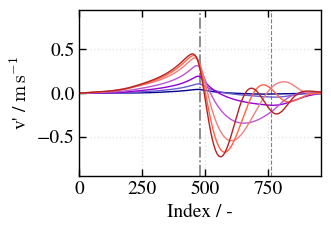

In [24]:
fig, (ax0) = plt.subplots(1,1,figsize=(3.5,2.5))
x = int(ds.nx/2)
xs = 760
ax0.axvline(x,c='grey',ls='-.',lw=1.25)
ax0.axvline(xs,c='grey',ls='dashed')

for i,ds in enumerate(ds_list):
    ax0.plot(ds['v'][6,5,y,:].values, color=COLS[i],lw=1)


ax0.grid(visible=True)
ax0.set_ylabel(r"v' / $\mathrm{m} \, \mathrm{s}^{-1}$")
ax0.set_xlabel("Index / -")
ax0.set_ylim((-0.95,0.95))
ax0.set_xlim((0,960))

fig_title = 'MWs-zprofiles-vprime.png'
fig.tight_layout()
fig.savefig('../figures/' + fig_title, facecolor='w', edgecolor='w',
                format='png', dpi=300, bbox_inches='tight')